/tmp/ipykernel_227737/2982282308.py:55: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(start="2001-01", periods=len(missing_pixels), freq="M")
/tmp/ipykernel_227737/2982282308.py:79: RuntimeWarning: Mean of empty slice
  bias=np.nanmean(abs(idata[:, :, 4]-esa_filled),axis=1)
/tmp/ipykernel_227737/2982282308.py:122: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


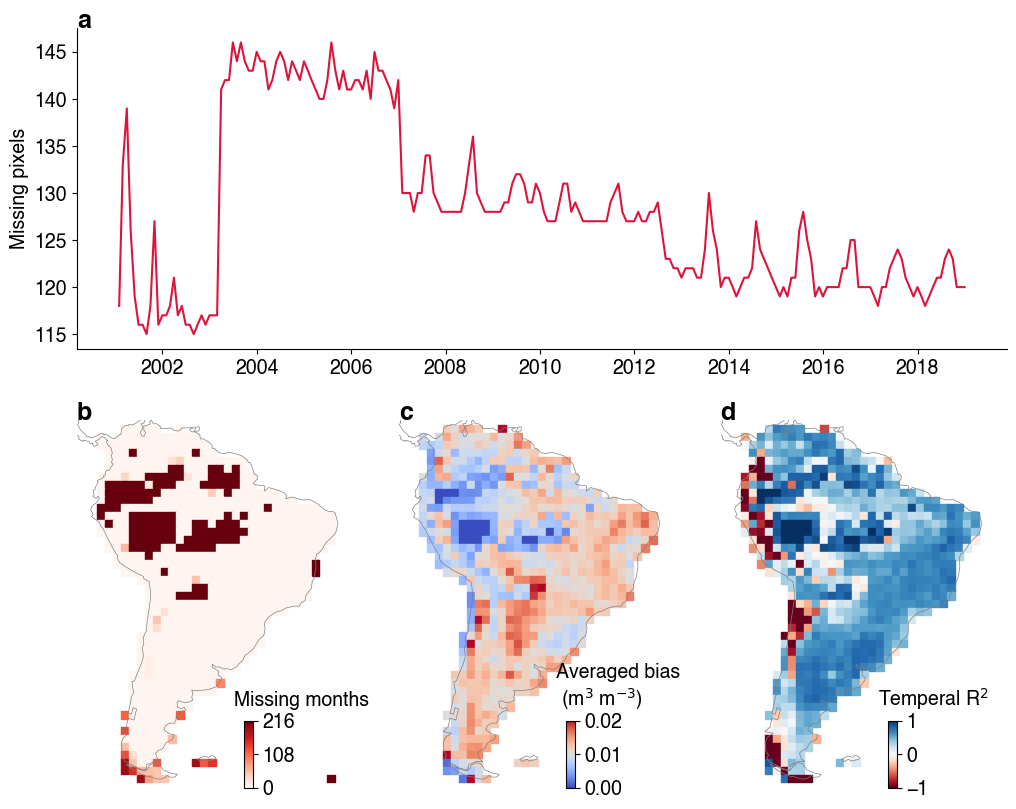

In [23]:
from matplotlib.colors import CenteredNorm,TwoSlopeNorm
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from shapely.geometry import Polygon
import cartopy.io.shapereader as shpreader
import pandas as pd
import numpy as np
from shapely.geometry import MultiPoint, Point
from scipy import stats
from shapely.ops import cascaded_union, polygonize
from scipy.spatial import Delaunay
import numpy as np
import math
from shapely import geometry
from shapely.geometry import MultiPoint, Point
from matplotlib.colors import CenteredNorm,TwoSlopeNorm
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from shapely.geometry import Polygon
import cartopy.io.shapereader as shpreader
import xarray as xr
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.ticker import ScalarFormatter
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from scipy.stats import norm
import matplotlib.font_manager as fm
import matplotlib.dates as mdates
fm.fontManager.addfont('/User/homes/fhuang/.fonts/Helvetica.ttf')
plt.rcParams['font.family'] = 'Helvetica'
fm.fontManager.addfont('/User/homes/fhuang/.fonts/Helvetica-Bold.ttf')
font_path1 = '/User/homes/fhuang/.fonts/Helvetica-Bold.ttf'
fm.fontManager.addfont(font_path1) 
prop1 = fm.FontProperties(fname=font_path1, size=18)

#----input-----
idata=np.load('/Net/Groups/BGI/scratch/fhuang/sm_uta_cnn/input_data/deseason_detrend/sm_4dataset.npy')
nan_idx=np.load('/Net/Groups/BGI/scratch/fhuang/sm_uta_cnn/conv3d_res/nan_idx.npy')
idata=np.delete(idata,nan_idx,axis=0)
esa_filled=np.squeeze(np.load('/Net/Groups/BGI/scratch/fhuang/sm_uta_cnn/input_data/deseason_detrend/esa_sa_filled2.npy'))
#-------------fig settings-------
fig = plt.figure(figsize=(12, 10))
fontsize=14
gs = plt.GridSpec(12, 9,wspace=0.5, hspace=0.)
#-----fig.a
ax0 = fig.add_subplot(gs[:5, 0:9])
missing_pixels=np.full([216],0)
for i in range(216):
    missing_pixels[i]=np.isnan(idata[:,i,6]).sum()


dates = pd.date_range(start="2001-01", periods=len(missing_pixels), freq="M")

df = pd.DataFrame({"date": dates, "v": missing_pixels})
ax0.plot(df.date.to_numpy(), df.v.to_numpy(),c='crimson')
ax0.set_ylabel("Missing pixels",fontsize=fontsize)
ax0.tick_params(labelsize=fontsize)
ax0.spines['right'].set_visible(False) 
ax0.spines['top'].set_visible(False)
#-----fig.b
subplot_kw=dict(projection=ccrs.PlateCarree())
ax1 = fig.add_subplot(gs[6:, 0:3],**subplot_kw,)
missing_days=np.full([737],np.nan)
for i in range(737):
    missing_days[i]=np.isnan(idata[i,:,6]).sum()
map1=ax1.scatter(idata[:,0,3],idata[:,0,2],s=30,c=missing_days, cmap='Reds',marker="s")
ax1.set_extent([-84, -30, -55, 11])
ax1.coastlines(color='grey', linewidth=0.5)
ax1.axis('off')
cb_map1 = inset_axes(ax1, width="5%",height="30%",borderpad=0, bbox_to_anchor=(0.3, -0.2, 0.6, 0.6), 
                     bbox_transform=ax1.transAxes, loc='center')
cb1=fig.colorbar(map1, cax=cb_map1,fraction=0.01,pad=0.1,shrink=1,ticks=[0,108,216])
cb1.ax.tick_params(labelsize=14)
#------fig d
ax3= fig.add_subplot(gs[6:, 3:6],**subplot_kw,)
bias=np.nanmean(abs(idata[:, :, 4]-esa_filled),axis=1)
map3=ax3.scatter(idata[:,0,3],idata[:,0,2],s=30,c=bias,norm=TwoSlopeNorm(vmin=0,vcenter=0.01,vmax=0.02), cmap='coolwarm',marker="s")
ax3.set_extent([-84, -30, -55, 11])
ax3.coastlines(color='grey', linewidth=0.5)
ax3.axis('off')
cb_map3 = inset_axes(ax3, width="5%",height="30%",borderpad=0, bbox_to_anchor=(0.3, -0.2, 0.6, 0.6), 
                     bbox_transform=ax3.transAxes, loc='center')
cb3=fig.colorbar(map3, cax=cb_map3,fraction=0.01,pad=0.1,shrink=1,ticks=[0,0.01,0.02])#
cb3.ax.tick_params(labelsize=14)

#------fig e
ax4= fig.add_subplot(gs[6:, 6:],**subplot_kw,)
r2list=[]
for i in range(737):
    try:
        r2list.append(r2_score(idata[i, :, 4],esa_filled[i,:]))
    except:
        r2list.append(np.nan)
map4=ax4.scatter(idata[:,0,3],idata[:,0,2],s=30,c=np.array(r2list), norm=TwoSlopeNorm(vmin=-1,vcenter=0,vmax=1),
                 cmap='RdBu',marker="s")
ax4.set_extent([-84, -30, -55, 11])
ax4.coastlines(color='grey', linewidth=0.5)
ax4.axis('off')
cb_map4 = inset_axes(ax4, width="5%",height="30%",borderpad=0, bbox_to_anchor=(0.3, -0.2, 0.6, 0.6), 
                     bbox_transform=ax4.transAxes, loc='center')
cb4=fig.colorbar(map4, cax=cb_map4,fraction=0.01,pad=0.1,shrink=1,ticks=[-1,0,1])
cb4.ax.tick_params(labelsize=14)

############
fm.fontManager.addfont('/User/homes/fhuang/.fonts/Helvetica-Bold.ttf')
font_path1 = '/User/homes/fhuang/.fonts/Helvetica-Bold.ttf'
fm.fontManager.addfont(font_path1) 
prop1 = fm.FontProperties(fname=font_path1, size=18)

ax0.text(0., 1., "a", transform=ax0.transAxes, fontsize=18, fontproperties=prop1, fontweight='bold')
ax1.text(0., 1., "b", transform=ax1.transAxes, fontsize=18, fontproperties=prop1, fontweight='bold')
ax3.text(0., 1., "c", transform=ax3.transAxes, fontsize=18, fontproperties=prop1, fontweight='bold')
ax4.text(0., 1., "d", transform=ax4.transAxes, fontsize=18, fontproperties=prop1, fontweight='bold')

ax1.text(0.55, 0.23, 'Missing months', transform=ax1.transAxes, fontsize=14,)
ax3.text(0.55, 0.23, 'Averaged bias\n (m$^{3}$ m$^{-3}$)', transform=ax3.transAxes, fontsize=14,)
ax4.text(0.55, 0.23, 'Temperal R$^2$', transform=ax4.transAxes, fontsize=14,)

fig.tight_layout()
fig.savefig('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/figs/figs10.pdf', dpi=300, format='pdf',bbox_inches='tight', pad_inches=0.)
fig.savefig('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/figs/figs10.tiff', dpi=300, bbox_inches='tight', pad_inches=0.)